# Markov Chain Analysis

checks momentum using a simple two state Markov chain. 

If tennis momentum exists in a point-to-point way, then the player who won the previous point should be more likely to win the next point.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("data/2024_Wimbledon_featured_matches.csv")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
df = pd.read_csv(DATA_PATH).reset_index(drop=True)

df["prev_point_victor"] = df.groupby("match_id")["point_victor"].shift(1)
df["prev_server"] = df.groupby("match_id")["server"].shift(1)
df["same_server_as_previous"] = df["server"] == df["prev_server"]
df["same_player_won_again"] = df["point_victor"] == df["prev_point_victor"]

transitions = df.dropna(subset=["prev_point_victor", "prev_server"]).copy()
transitions[["match_id", "server", "prev_server", "prev_point_victor", "point_victor", "same_server_as_previous"]].head()

,match_id,server,prev_server,prev_point_victor,point_victor,same_server_as_previous
1,2023-wimbledon-1301,1,1.0,2.0,1,True
2,2023-wimbledon-1301,1,1.0,1.0,2,True
3,2023-wimbledon-1301,1,1.0,2.0,1,True
4,2023-wimbledon-1301,1,1.0,1.0,1,True
5,2023-wimbledon-1301,1,1.0,1.0,2,True


## Transition Matrix Helper

Rows represent the previous point winner. Columns represent the next/current point winner. For example, the row `previous: player 1` gives the probability that player 1 or player 2 wins the next point after player 1 won the previous point.

In [3]:
def transition_matrix(data):
    counts = pd.crosstab(data["prev_point_victor"], data["point_victor"])
    counts = counts.reindex(index=[1.0, 2.0], columns=[1, 2], fill_value=0)
    probs = counts.div(counts.sum(axis=1), axis=0)
    probs.index = ["previous: player 1", "previous: player 2"]
    probs.columns = ["next: player 1", "next: player 2"]
    return counts, probs


def continuation_rate(data):
    return data["same_player_won_again"].mean()


overall_counts, overall_probs = transition_matrix(transitions)
overall_probs

,next: player 1,next: player 2
previous: player 1,0.543537,0.456463
previous: player 2,0.476512,0.523488


## Split by Serve Context

If the Markov pattern changes a lot depending on whether the server stayed the same, then the apparent momentum is probably connected to serving structure.

In [4]:
same_server = transitions[transitions["same_server_as_previous"]].copy()
server_changed = transitions[~transitions["same_server_as_previous"]].copy()

same_server_counts, same_server_probs = transition_matrix(same_server)
server_changed_counts, server_changed_probs = transition_matrix(server_changed)

same_server_probs

,next: player 1,next: player 2
previous: player 1,0.566799,0.433201
previous: player 2,0.444406,0.555594


In [5]:
server_changed_probs

,next: player 1,next: player 2
previous: player 1,0.439169,0.560831
previous: player 2,0.620000,0.380000


In [6]:
markov_summary = pd.DataFrame(
    {
        "context": ["all transitions", "same server", "server changed"],
        "n_transitions": [len(transitions), len(same_server), len(server_changed)],
        "same_player_wins_again": [
            continuation_rate(transitions),
            continuation_rate(same_server),
            continuation_rate(server_changed),
        ],
        "p1_repeats_after_p1_win": [
            overall_probs.loc["previous: player 1", "next: player 1"],
            same_server_probs.loc["previous: player 1", "next: player 1"],
            server_changed_probs.loc["previous: player 1", "next: player 1"],
        ],
        "p2_repeats_after_p2_win": [
            overall_probs.loc["previous: player 2", "next: player 2"],
            same_server_probs.loc["previous: player 2", "next: player 2"],
            server_changed_probs.loc["previous: player 2", "next: player 2"],
        ],
    }
)

markov_summary

,context,n_transitions,same_player_wins_again,p1_repeats_after_p1_win,p2_repeats_after_p2_win
0,all transitions,7253,0.533710,0.543537,0.523488
1,same server,5929,0.561309,0.566799,0.555594
2,server changed,1324,0.410121,0.439169,0.380000


## Heatmap Figure

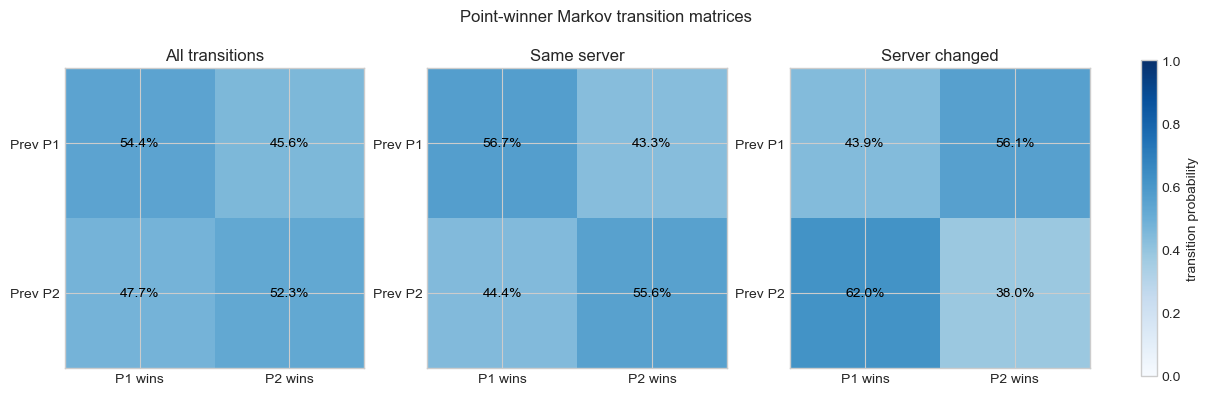

In [7]:
matrices = [overall_probs, same_server_probs, server_changed_probs]
titles = ["All transitions", "Same server", "Server changed"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
for ax, matrix, title in zip(axes, matrices, titles):
    im = ax.imshow(matrix.values, vmin=0, vmax=1, cmap="Blues")
    ax.set_title(title)
    ax.set_xticks([0, 1], labels=["P1 wins", "P2 wins"])
    ax.set_yticks([0, 1], labels=["Prev P1", "Prev P2"])
    for i in range(2):
        for j in range(2):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.1%}", ha="center", va="center", color="black")

fig.colorbar(im, ax=axes, shrink=0.85, label="transition probability")
fig.suptitle("Point-winner Markov transition matrices", y=1.05)
fig.savefig(FIGURE_DIR / "markov_transition_matrices.png", dpi=200, bbox_inches="tight")
plt.show()